In [ ]:
# common imports
import os
import time
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, precision_recall_fscore_support, f1_score

# audio libraries
import librosa
import audiomentations
import IPython.display as ipd

# modeling imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torchvision import transforms
import torchvision.models as models

# osprey package
from osprey import (
    AudioDataset,
    SimpleCNN,
    clean_row,
    duration,
    fmax,
    fmin,
    get_audio,
    get_mel,
    height,
    highest_folder,
    map_collection,
    reformat_image,
    sr,
    width,
)

# notebook config
num_epochs = 2
batch_size = 2 * 7
num_workers = 8
train_loss_path = "training_loss.csv"
validate_loss_path = "validate_loss.csv"
summary_path = "summary.csv"

# documentation
import numpy.typing as npt
from typing import Optional, Union

In [2]:
# Check if a GPU is available
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
else:
    device = torch.device("cpu")
    print("GPU not available, using CPU instead.")

GPU is available: NVIDIA A40
Number of GPUs: 1


In [ ]:
# only birdclef-2026 data
meta = meta[meta['collection'].isin(['XC','iNat'])]

# subsets
train_data = meta[meta['dataset']=='train'].copy()
le = LabelEncoder() # label encoder
le.fit(train_data['primary_label'])
val_data = meta[meta['dataset']=='validate'].copy()
test_data = meta[meta['dataset']=='test'].copy()

# reset indices
train_data.reset_index(inplace=True, drop=True)
val_data.reset_index(inplace=True, drop=True)
test_data.reset_index(inplace=True, drop=True)

# unique species in datasets
train_species = np.array(train_data.primary_label.unique())
val_species = np.array(val_data.primary_label.unique())
test_species = np.array(train_data.primary_label.unique())
test_species

array(['1161364', '116570', '22967', '22985', '23154', '41970', '516975',
       '555123', '74580', 'brnowl', 'grekis', 'houspa', 'socfly1',
       'sptnig1', 'trsowl', 'whtdov', 'whwpic1'], dtype=object)

Tropical Screech Owl


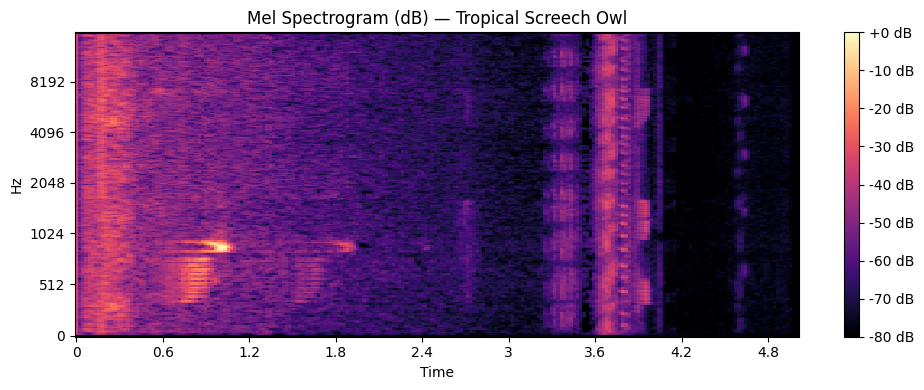

In [ ]:
# listen to an example audio
idx = 10000
row = clean_row(train_data.iloc[idx])
y, _ = get_audio(row, sr=sr)
x, h = get_mel(y, sr)
print(row['common_name'])

# plot mel spectrogram in dB (power scale)
X_db = librosa.power_to_db(x.T, ref=np.max)  # transpose so rows = mel bins
plt.figure(figsize=(10, 4))
librosa.display.specshow(X_db, sr=int(sr), hop_length=int(h),
                         x_axis='time', 
                         y_axis='mel', 
                         fmin=fmin, 
                         fmax=fmax, 
                         cmap='magma',
                         )
plt.colorbar(format='%+2.0f dB')
plt.title(f"Mel Spectrogram (dB) — {row['common_name']}")
plt.tight_layout()
plt.show()

ipd.Audio(y, rate=sr)

In [ ]:
# smaller subset: 8 batches of 32 samples = 256
n_samples = 1e8
num_classes = len(primary_labels)

# sample from test split (use .head(n_samples) instead of .sample(...) if you want deterministic order)
train_data_small = train_data.sample(n=min(n_samples, len(train_data)), random_state=42).reset_index(drop=True)
val_data_small = val_data.sample(n=min(n_samples, len(val_data)), random_state=42).reset_index(drop=True)

# optional: overwrite active dataset/dataloader to use the small subset
dataset_train = AudioDataset(train_data_small, le, sr=sr)
dataloader_train = DataLoader(dataset_train, batch_size=batch_size, num_workers=num_workers, shuffle=False)
dataset_val = AudioDataset(val_data_small, le, sr=sr)
dataloader_val = DataLoader(dataset_val, batch_size=batch_size, num_workers=num_workers, shuffle=False)
le = dataset_train.le

print("Number of training samples:", len(train_data_small))
print("Number of batches:", len(dataloader_train))

Number of training samples: 16271
Number of batches: 1163


In [106]:
weights = models.EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features, num_classes),
)

# criterion = nn.BCEWithLogitsLoss()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

model.to(device)

print()

In [115]:
# total parameter counts
total_params = sum(p.numel() for p in model.parameters())

# # freeze all but the last layer
# for param in model.parameters():
#     param.requires_grad = False
# for param in model.classifier.parameters():
#     param.requires_grad = True

# unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

# trainable parameter counts
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# printing summary
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {total_params - trainable_params:,}")

Total parameters: 4,031,887
Trainable parameters: 4,031,887
Non-trainable parameters: 0


In [ ]:
image_size = (height, width)
channel_size = 3

ft = open(train_loss_path, 'w')
fv = open(validate_loss_path, 'w')
ft.write('epoch,loss\n')
fv.write('epoch,loss\n')

for _ in range(1, num_epochs + 1):

    # learning
    model.train()
    loss_total = 0
    itr = 0
    curr_time = time.time()
    for X, Y in dataloader_train:
        itr += 1
        if (itr % 100) == 0:
            print(f'{itr/len(dataloader_train)*100:.2f}%')
        optimizer.zero_grad()
        Z = reformat_image(X, 
                           image_size=image_size, 
                           channel_size=channel_size,
                           ).to(device)
        Y = Y.to(device)
        logits = model(Z)
        loss = criterion(logits, Y)
        loss_total += loss
        loss.backward()
        optimizer.step()
    print(f'Epoch {_} took {time.time() - curr_time:0f} seconds')
    print('')

    # # inference
    # model.eval()
    # with torch.no_grad():

    #     # training loss tracking
    #     loss_total = 0
    #     itr = 0
    #     for X, Y in dataloader_train:
    #         itr += 1
    #         Z = reformat_image(X, 
    #                        image_size=image_size, 
    #                        channel_size=channel_size,
    #                        ).to(device)
    #         Y = Y.to(device)
    #         logits = model(Z)
    #         loss = criterion(logits, Y)
    #         loss_total += loss
    #     print(f'The training loss at epoch {_} is {loss_total / itr:6f}')
    #     ft.write(f"{_},{loss_total / itr:4f}\n")

    #     # validation loss tracking
    #     loss_total = 0
    #     itr = 0
    #     for X, Y in dataloader_val:
    #         itr += 1
    #         Z = reformat_image(X, 
    #                        image_size=image_size, 
    #                        channel_size=channel_size,
    #                        ).to(device)
    #         Y = Y.to(device)
    #         logits = model(Z)
    #         loss = criterion(logits, Y)
    #         loss_total += loss
    #     print(f'The validation loss at epoch {_} is {loss_total / itr:6f}')
    #     fv.write(f"{_},{loss_total / itr:4f}\n")
    
    # print('')

ft.close()
fv.close()

8.60%
17.20%
25.80%
34.39%
42.99%
51.59%
60.19%
68.79%
77.39%
85.98%
94.58%
Epoch 1 took 81.945028 seconds

8.60%
17.20%
25.80%
34.39%
42.99%
51.59%
60.19%
68.79%
77.39%
85.98%
94.58%
Epoch 2 took 86.110590 seconds



In [ ]:
f0 = open(summary_path,'w')
f0.write('category,precision,recall,f1_score\n')

# some initial summary statistics

loss_total = 0.0
n_batches = 0
dataloader = dataloader_train
species = train_species

model.eval()

# Initialize empty lists to hold batch tensors
y_true_all = []
y_pred_all = []

with torch.no_grad():
    for X, Y_batch in dataloader:
        # Move everything to device immediately
        Z_batch = reformat_image(X, 
                                 image_size=image_size, 
                                 channel_size=channel_size).to(device)
        Y_batch = Y_batch.to(device) 
        
        logits = model(Z_batch)
        loss = criterion(logits, Y_batch) # Keep loss on GPU

        val_loss_total += loss.item()
        n_batches += 1

        # Store the batch tensors directly
        y_true_all.append(Y_batch)
        y_pred_all.append(logits.argmax(dim=1))

# Concatenate all batches at once and move to CPU only once
y_true = torch.cat(y_true_all).cpu().numpy()
y_pred = torch.cat(y_pred_all).cpu().numpy()

# write metrics
f0.write('overall,')
f0.write(f"{precision_score(y_true, y_pred, average='macro', zero_division=0):.2f},")
f0.write(f"{recall_score(y_true, y_pred, average='macro', zero_division=0):.2f},")
f0.write(f"{f1_score(y_true, y_pred, average='macro', zero_division=0):.2f}")
f0.write('\n')

# metrics for every class
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None, zero_division=0
)

for i, (p, r, f) in enumerate(zip(precision, recall, f1)):
    s = le.inverse_transform([i])[0]
    f0.write(f"{s},{p:.2f},{r:.2f},{f:.2f}\n")

f0.close()

IndexError: index 17 is out of bounds for axis 0 with size 17

In [203]:
species

array(['1161364', '116570', '22967', '22985', '23154', '41970', '516975',
       '555123', '74580', 'brnowl', 'grekis', 'houspa', 'socfly1',
       'sptnig1', 'trsowl', 'whtdov', 'whwpic1'], dtype=object)

In [ ]:
f0 = open(summary_path,'w')

f0.write('category,precision,recall,f1_score\n')

# write metrics
f0.write('overall,')
f0.write(f"{precision_score(y_true, y_pred, average='macro', zero_division=0):.2f},")
f0.write(f"{recall_score(y_true, y_pred, average='macro', zero_division=0):.2f},")
f0.write(f"{f1_score(y_true, y_pred, average='macro', zero_division=0):.2f}")
f0.write('\n')

# metrics for every class
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
for i, _ in enumerate(precision):
    # s = le.inverse_transform([i])
    f0.write(f",{_:.2f},,\n")
# for i, _ in enumerate(recall):
#     f0.write(f"{_:.2f},")
# for i, _ in enumerate(f1):
#     f0.write(f"{_:.2f}\n")

f0.close()

In [205]:
f0.close()